In [2]:
# Imports
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

### Data Preprocessing

In [3]:
def first_existing_path(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError("None of these paths exist:\n" + "\n".join(str(Path(c)) for c in candidates))


small_flow_path = first_existing_path([
    "./TrafficProject/results/task3_flow_timeseries_5sec.csv",
    "./TrafficProject/results/task3_flow_timeseries.csv",
    "./Data/TrafficProject/results/task3_flow_timeseries_5sec.csv",
    "./Data/TrafficProject/results/task3_flow_timeseries.csv",
])

combined_flow_path = first_existing_path([
    "../Data_2_v2_combined/results/flow_10s_all.csv",
    "../Data_2_v2/results/flow_10s_all.csv",
    "../Exercise_3/results/flow_10s_all.csv",
    "./Data_2_v2_combined/results/flow_10s_all.csv",
    "./Data_2_v2/results/flow_10s_all.csv",
    "./Exercise_3/results/flow_10s_all.csv",
])

print(f"Small one-crossroad dataset: {small_flow_path}")
print(f"Bigger combined dataset:     {combined_flow_path}")

Small one-crossroad dataset: TrafficProject\results\task3_flow_timeseries_5sec.csv
Bigger combined dataset:     ..\Exercise_3\results\flow_10s_all.csv


In [4]:
def prepare_flow_dataset(path, dataset_name, detection_scale=40):
    flow_raw = pd.read_csv(path)

    required_columns = {"west_in", "east_in", "north_in", "south_in"}
    missing_columns = required_columns.difference(flow_raw.columns)
    if missing_columns:
        raise ValueError(f"Missing columns in {dataset_name}: {sorted(missing_columns)}")

    if "time_bin_5sec" in flow_raw.columns:
        time_step_seconds = 5
        time_column = "time_bin_5sec"
    elif "time_bin" in flow_raw.columns:
        time_step_seconds = 10
        time_column = "time_bin"
    elif "frame_id" in flow_raw.columns:
        time_step_seconds = 1
        time_column = "frame_id"
    else:
        time_step_seconds = 1
        time_column = None

    # If the combined file contains multiple source roads, aggregate them per time bin.
    group_columns = [time_column] if time_column else []
    if group_columns:
        flow = flow_raw.groupby(group_columns, as_index=False)[list(required_columns)].sum()
    else:
        flow = flow_raw.copy()

    if time_column:
        flow["time_s"] = flow[time_column] * time_step_seconds
    else:
        flow["time_s"] = np.arange(len(flow)) * time_step_seconds

    flow["ns_arrivals"] = (flow["north_in"] + flow["south_in"]) / detection_scale
    flow["ew_arrivals"] = (flow["east_in"] + flow["west_in"]) / detection_scale
    flow["total_arrivals"] = flow["ns_arrivals"] + flow["ew_arrivals"]
    flow.attrs["dataset_name"] = dataset_name
    flow.attrs["time_step_seconds"] = time_step_seconds
    flow.attrs["source_path"] = str(path)
    return flow

In [5]:
traffic_small = prepare_flow_dataset(small_flow_path, "Dataset_v1")
traffic_combined = prepare_flow_dataset(combined_flow_path, "Dataset_v2_combined")

dataset_summary = pd.DataFrame([
    {
        "dataset": traffic_small.attrs["dataset_name"],
        "rows": len(traffic_small),
        "time_step_seconds": traffic_small.attrs["time_step_seconds"],
        "avg_ns_arrivals": traffic_small["ns_arrivals"].mean(),
        "avg_ew_arrivals": traffic_small["ew_arrivals"].mean(),
        "avg_total_arrivals": traffic_small["total_arrivals"].mean(),
    },
    {
        "dataset": traffic_combined.attrs["dataset_name"],
        "rows": len(traffic_combined),
        "time_step_seconds": traffic_combined.attrs["time_step_seconds"],
        "avg_ns_arrivals": traffic_combined["ns_arrivals"].mean(),
        "avg_ew_arrivals": traffic_combined["ew_arrivals"].mean(),
        "avg_total_arrivals": traffic_combined["total_arrivals"].mean(),
    },
])

dataset_summary.head()

,dataset,rows,time_step_seconds,avg_ns_arrivals,avg_ew_arrivals,avg_total_arrivals
0,Dataset_v1,164,5,1.297561,4.420884,5.718445
1,Dataset_v2_combined,84,10,0.107440,0.158036,0.265476


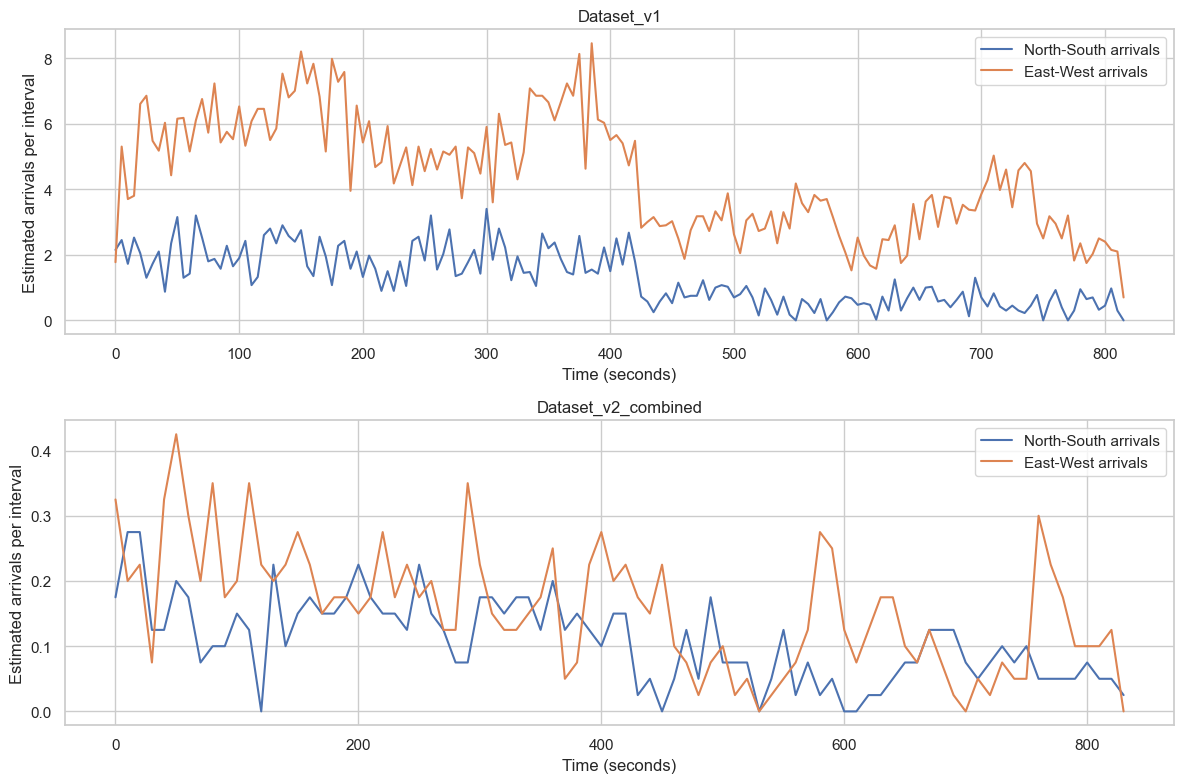

In [6]:
def plot_traffic_demand(datasets):
    fig, axes = plt.subplots(len(datasets), 1, figsize=(12, 4 * len(datasets)), sharex=False)
    if len(datasets) == 1:
        axes = [axes]

    for ax, flow in zip(axes, datasets):
        ax.plot(flow["time_s"], flow["ns_arrivals"], label="North-South arrivals")
        ax.plot(flow["time_s"], flow["ew_arrivals"], label="East-West arrivals")
        ax.set_title(flow.attrs["dataset_name"])
        ax.set_xlabel("Time (seconds)")
        ax.set_ylabel("Estimated arrivals per interval")
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_traffic_demand([traffic_small, traffic_combined])

### Cycle

In [7]:
MIN_GREEN = 10
MAX_GREEN = 90
LOST_TIME_SECONDS = 4
SATURATION_RATE = 1.5  # estimated vehicles discharged per green second

In [8]:
def decode_plan(individual):
    green_ns = int(np.clip(round(individual[0]), MIN_GREEN, MAX_GREEN))
    green_ew = int(np.clip(round(individual[1]), MIN_GREEN, MAX_GREEN))
    start_phase = int(round(individual[2])) % 2
    order = "NS first" if start_phase == 0 else "EW first"
    cycle_length = green_ns + green_ew + 2 * LOST_TIME_SECONDS

    return {
        "green_ns": green_ns,
        "green_ew": green_ew,
        "start_phase": start_phase,
        "order": order,
        "cycle_length": cycle_length,
    }

In [9]:
def build_cycle(plan):
    if plan["start_phase"] == 0:
        phases = [("NS", plan["green_ns"]), ("ALL_RED", LOST_TIME_SECONDS), ("EW", plan["green_ew"]), ("ALL_RED", LOST_TIME_SECONDS)]
    else:
        phases = [("EW", plan["green_ew"]), ("ALL_RED", LOST_TIME_SECONDS), ("NS", plan["green_ns"]), ("ALL_RED", LOST_TIME_SECONDS)]

    signal = []
    for phase, duration in phases:
        signal.extend([phase] * int(duration))
    return signal


In [10]:
def simulation(individual, flow_df, return_trace=False):
    plan = decode_plan(individual)
    signal = build_cycle(plan)
    time_step_seconds = flow_df.attrs.get("time_step_seconds", 1)

    queue_ns = 0.0
    queue_ew = 0.0
    total_wait = 0.0
    total_served_ns = 0.0
    total_served_ew = 0.0
    trace = []
    second = 0

    for _, row in flow_df.iterrows():
        ns_arrivals_per_second = row["ns_arrivals"] / time_step_seconds
        ew_arrivals_per_second = row["ew_arrivals"] / time_step_seconds

        for _ in range(time_step_seconds):
            queue_ns += ns_arrivals_per_second
            queue_ew += ew_arrivals_per_second

            # One car waiting for one second contributes one vehicle-second.
            total_wait += queue_ns + queue_ew

            active_phase = signal[second % plan["cycle_length"]]
            if active_phase == "NS":
                served = min(queue_ns, SATURATION_RATE)
                queue_ns -= served
                total_served_ns += served
            elif active_phase == "EW":
                served = min(queue_ew, SATURATION_RATE)
                queue_ew -= served
                total_served_ew += served

            second += 1

        if return_trace:
            trace.append({
                "time_s": row["time_s"],
                "queue_ns": queue_ns,
                "queue_ew": queue_ew,
                "total_queue": queue_ns + queue_ew,
                "phase": signal[(second - 1) % plan["cycle_length"]],
            })

    residual_queue = queue_ns + queue_ew
    objective = total_wait + residual_queue * plan["cycle_length"]

    result = {
        "plan": plan,
        "objective": objective,
        "total_wait": total_wait,
        "residual_queue": residual_queue,
        "served_ns": total_served_ns,
        "served_ew": total_served_ew,
    }

    if return_trace:
        result["trace"] = pd.DataFrame(trace)

    return result

### Genetic Algorithm

In [11]:
def create_individual():
    return [
        random.randint(MIN_GREEN, MAX_GREEN),
        random.randint(MIN_GREEN, MAX_GREEN),
        random.randint(0, 1),
    ]

In [12]:
def fitness_function(individual, flow_df):
    return -simulation(individual, flow_df)["objective"]

In [13]:
def selection(scored_population, k=3):
    candidates = random.sample(scored_population, k)
    return max(candidates, key=lambda item: item[1])[0].copy()

In [14]:
def crossover(parent1, parent2, crossover_rate=0.85):
    if random.random() > crossover_rate:
        return parent1.copy(), parent2.copy()

    point = random.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

In [15]:
def mutate(individual, mutation_rate=0.2):
    mutated = individual.copy()

    for i in [0, 1]:
        if random.random() < mutation_rate:
            mutated[i] += random.randint(-12, 12)
            mutated[i] = int(np.clip(mutated[i], MIN_GREEN, MAX_GREEN))

    if random.random() < mutation_rate:
        mutated[2] = 1 - int(mutated[2])

    return mutated

In [16]:
def run_ga(flow_df, generations=80, population_size=60, elite_size=4, mutation_rate=0.2, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    population = [create_individual() for _ in range(population_size)]
    history = []
    best_individual = None
    best_fitness = float("-inf")

    for generation in range(generations):
        scored = [(individual, fitness_function(individual, flow_df)) for individual in population]
        scored.sort(key=lambda item: item[1], reverse=True)

        generation_best, generation_best_fitness = scored[0]
        if generation_best_fitness > best_fitness:
            best_fitness = generation_best_fitness
            best_individual = generation_best.copy()

        history.append({
            "generation": generation,
            "best_wait": -best_fitness,
            "generation_best_wait": -generation_best_fitness,
            "average_wait": -np.mean([score for _, score in scored]),
        })

        next_population = [individual.copy() for individual, _ in scored[:elite_size]]

        while len(next_population) < population_size:
            parent1 = selection(scored)
            parent2 = selection(scored)
            child1, child2 = crossover(parent1, parent2)
            next_population.append(mutate(child1, mutation_rate))
            if len(next_population) < population_size:
                next_population.append(mutate(child2, mutation_rate))

        population = next_population

    return best_individual, pd.DataFrame(history)

### Solutions

In [17]:
fixed_individual = [30, 30, 0]

# Solution 1: fixed timing on the original one-crossroad dataset
fixed_result = simulation(fixed_individual, traffic_small, return_trace=True)

# Solution 2: GA optimized on the small one-crossroad dataset
small_best_individual, small_history = run_ga(traffic_small, seed=42)
small_result = simulation(small_best_individual, traffic_small, return_trace=True)

# Solution 3: GA optimized on the bigger combined dataset
combined_best_individual, combined_history = run_ga(traffic_combined, seed=42)
combined_result = simulation(combined_best_individual, traffic_combined, return_trace=True)

comparison = pd.DataFrame([
    {
        "solution": "Fixed timing",
        "dataset": "One crossroad small",
        "individual": fixed_individual,
        **fixed_result["plan"],
        "objective": fixed_result["objective"],
        "total_wait": fixed_result["total_wait"],
        "residual_queue": fixed_result["residual_queue"],
    },
    {
        "solution": "GA small dataset",
        "dataset": "One crossroad small",
        "individual": small_best_individual,
        **small_result["plan"],
        "objective": small_result["objective"],
        "total_wait": small_result["total_wait"],
        "residual_queue": small_result["residual_queue"],
    },
    {
        "solution": "GA bigger dataset",
        "dataset": "Data_2_v2 combined",
        "individual": combined_best_individual,
        **combined_result["plan"],
        "objective": combined_result["objective"],
        "total_wait": combined_result["total_wait"],
        "residual_queue": combined_result["residual_queue"],
    },
])

comparison["improvement_vs_fixed_small_%"] = 100 * (fixed_result["objective"] - comparison["objective"]) / fixed_result["objective"]


In [18]:

# Fair cross-evaluation: apply each learned schedule to both datasets.
solution_schedules = {
    "Fixed timing": fixed_individual,
    "GA small dataset": small_best_individual,
    "GA bigger dataset": combined_best_individual,
}

evaluation_datasets = {
    "One crossroad small": traffic_small,
    "Data_2_v2 combined": traffic_combined,
}

cross_evaluation_rows = []
for solution_name, individual in solution_schedules.items():
    for dataset_name, flow_df in evaluation_datasets.items():
        result = simulation(individual, flow_df)
        cross_evaluation_rows.append({
            "solution": solution_name,
            "evaluated_on": dataset_name,
            "objective": result["objective"],
            "total_wait": result["total_wait"],
            "residual_queue": result["residual_queue"],
            **result["plan"],
        })

cross_evaluation = pd.DataFrame(cross_evaluation_rows)

comparison.head()

,solution,dataset,individual,green_ns,green_ew,start_phase,order,cycle_length,objective,total_wait,residual_queue,improvement_vs_fixed_small_%
0,Fixed timing,One crossroad small,"[30, 30, 0]",30,30,0,NS first,68,145599.9850,133018.2850,185.025,0.000000
1,GA small dataset,One crossroad small,"[22, 68, 0]",22,68,0,NS first,98,34184.5050,33983.1150,2.055,76.521629
2,GA bigger dataset,Data_2_v2 combined,"[10, 13, 0]",10,13,0,NS first,31,161.1575,161.1575,0.000,99.889315


In [19]:
print("Fixed plan:")
print(fixed_result["plan"])
print()

print("GA optimized on small one-crossroad dataset:")
print(f"Best individual: {small_best_individual}")
print(f"Plan: {small_result['plan']}")
print(f"Improvement over fixed timing on the same small dataset: {comparison.loc[1, 'improvement_vs_fixed_small_%']:.2f}%")
print()

print("GA optimized on bigger combined dataset:")
print(f"Best individual: {combined_best_individual}")
print(f"Plan: {combined_result['plan']}")

cross_evaluation

Fixed plan:
{'green_ns': 30, 'green_ew': 30, 'start_phase': 0, 'order': 'NS first', 'cycle_length': 68}

GA optimized on small one-crossroad dataset:
Best individual: [22, 68, 0]
Plan: {'green_ns': 22, 'green_ew': 68, 'start_phase': 0, 'order': 'NS first', 'cycle_length': 98}
Improvement over fixed timing on the same small dataset: 76.52%

GA optimized on bigger combined dataset:
Best individual: [10, 13, 0]
Plan: {'green_ns': 10, 'green_ew': 13, 'start_phase': 0, 'order': 'NS first', 'cycle_length': 31}


,solution,evaluated_on,objective,total_wait,residual_queue,green_ns,green_ew,start_phase,order,cycle_length
0,Fixed timing,One crossroad small,145599.9850,133018.2850,185.025,30,30,0,NS first,68
1,Fixed timing,Data_2_v2 combined,266.6150,252.6750,0.205,30,30,0,NS first,68
2,GA small dataset,One crossroad small,34184.5050,33983.1150,2.055,22,68,0,NS first,98
3,GA small dataset,Data_2_v2 combined,363.4900,348.3000,0.155,22,68,0,NS first,98
4,GA bigger dataset,One crossroad small,144302.0600,137543.2850,218.025,10,13,0,NS first,31
5,GA bigger dataset,Data_2_v2 combined,161.1575,161.1575,0.000,10,13,0,NS first,31


### Visualization and Comparison

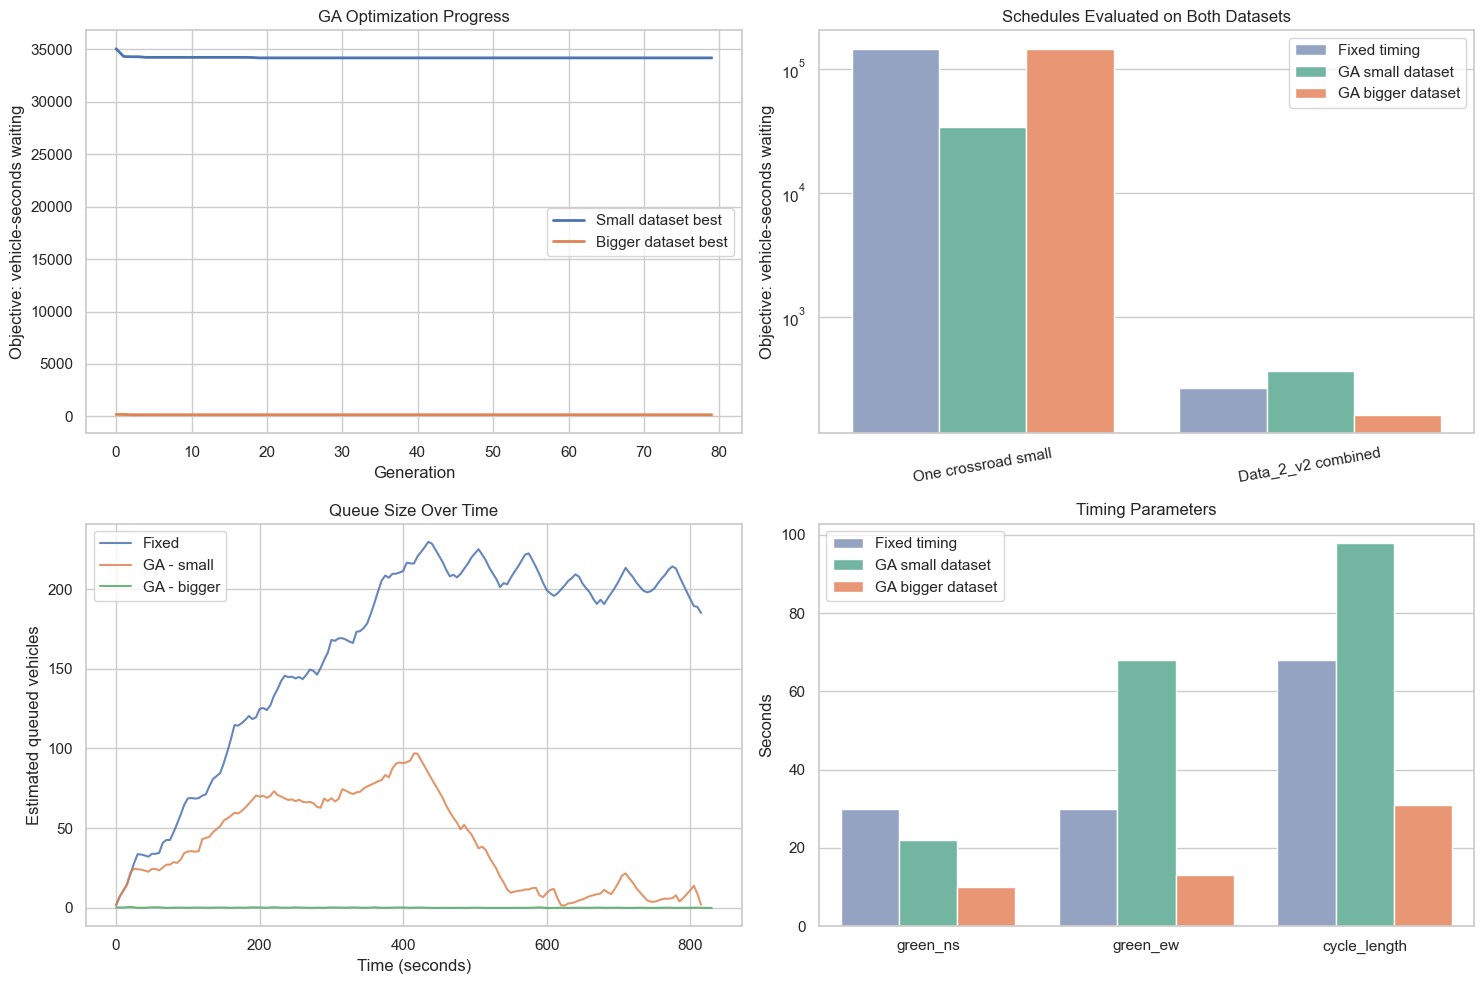

In [20]:
def visualize_three_solutions(comparison, cross_evaluation, fixed_result, small_result, combined_result, small_history, combined_history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(small_history["generation"], small_history["best_wait"], label="Small dataset best", linewidth=2)
    axes[0, 0].plot(combined_history["generation"], combined_history["best_wait"], label="Bigger dataset best", linewidth=2)
    axes[0, 0].set_title("GA Optimization Progress")
    axes[0, 0].set_xlabel("Generation")
    axes[0, 0].set_ylabel("Objective: vehicle-seconds waiting")
    axes[0, 0].legend()

    sns.barplot(data=cross_evaluation, x="evaluated_on", y="objective", hue="solution", ax=axes[0, 1], palette=["#8da0cb", "#66c2a5", "#fc8d62"])
    axes[0, 1].set_title("Schedules Evaluated on Both Datasets")
    axes[0, 1].set_xlabel("")
    axes[0, 1].set_ylabel("Objective: vehicle-seconds waiting")
    axes[0, 1].set_yscale("log")
    axes[0, 1].tick_params(axis="x", rotation=10)
    axes[0, 1].legend(title="")

    fixed_trace = fixed_result["trace"]
    small_trace = small_result["trace"]
    combined_trace = combined_result["trace"]
    axes[1, 0].plot(fixed_trace["time_s"], fixed_trace["total_queue"], label="Fixed", alpha=0.85)
    axes[1, 0].plot(small_trace["time_s"], small_trace["total_queue"], label="GA - small", alpha=0.85)
    axes[1, 0].plot(combined_trace["time_s"], combined_trace["total_queue"], label="GA - bigger", alpha=0.85)
    axes[1, 0].set_title("Queue Size Over Time")
    axes[1, 0].set_xlabel("Time (seconds)")
    axes[1, 0].set_ylabel("Estimated queued vehicles")
    axes[1, 0].legend()

    plan_table = comparison[["solution", "green_ns", "green_ew", "cycle_length"]].melt(
        id_vars=["solution"],
        value_vars=["green_ns", "green_ew", "cycle_length"],
        var_name="parameter",
        value_name="seconds",
    )
    sns.barplot(data=plan_table, x="parameter", y="seconds", hue="solution", ax=axes[1, 1], palette=["#8da0cb", "#66c2a5", "#fc8d62"])
    axes[1, 1].set_title("Timing Parameters")
    axes[1, 1].set_xlabel("")
    axes[1, 1].set_ylabel("Seconds")
    axes[1, 1].legend(title="")

    plt.tight_layout()
    plt.show()


visualize_three_solutions(comparison, cross_evaluation, fixed_result, small_result, combined_result, small_history, combined_history)

### Conclusion

We have studied with simulation how three solutions would work. As the baseline we took fixed timing strategy, 2 GA where one has only one crossroad and second with two crossroads. Let's call them Fixed, 1-Ga, 2-GA

1-GA performed well but the cycle is longer than Fixed has. That can cause more queue to other streets. But still relevant for highways and where distance between traffic lights.
According to results the shortest cycle and most effective green lights timing has 2-GA. It gives good solution for global solutions where distance of traffic lights is shorter but not cycled. So when car crosses two crossroades straight ahead it will shows the best perfomance.
To improve GA solution we should add pedestrians and even more crossrodes where they have minimum 2 crossroads connections 